# CIFAR-10 Image Classification Model
## Build and Compare ANN vs CNN on CIFAR-10

This structured notebook serves as a comprehensive pipeline demonstrating the fundamental mechanical differences between **Artificial Neural Networks (ANN)** and **Convolutional Neural Networks (CNN)** when applied to image data. We will progressively build, train, and evaluate distinct architectures, applying modern regularization strategies to optimize final performance.

**Primary Objectives:**
* Successfully ingest and normalize the standard CIFAR-10 tensor arrays.
* Establish a baseline performance metric using a dense, flattened neural network.
* Construct a deep spatial convolutional model with progressive filter scaling.
* Implement dynamic training upgrades including data augmentation and early stopping.

# Environment Setup

Deep learning requires a robust computational environment. We import **TensorFlow** and **Keras** to natively construct our neural architectures and handle tensor calculus. **Matplotlib** and **Pandas** are included to visualize our learning curves and tabularize our final evaluation metrics.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### Observation
* The environment successfully initializes the **TensorFlow** background engine.
* High-level **Keras** APIs are bound and ready for sequential model building.
* Data structuring and visualization modules are loaded into the active memory space.

# Load Dataset

The **CIFAR-10** dataset serves as our standard benchmark, containing 60,000 color images distributed across ten distinct classes. By loading this directly through the Keras API, we ensure a clean, standardized structural split between our isolated training and testing data subsets.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training input shape:", x_train.shape)
print("Testing input shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training input shape: (50000, 32, 32, 3)
Testing input shape: (10000, 32, 32, 3)


### Observation
* The raw dataset provisions exactly **50,000 training images** and **10,000 test images**.
* The terminal output confirms the input tensors represent a 32x32 resolution with 3 color channels.
* Loading directly via Keras circumvents local pathing errors and standardizes the array structures.

# Preprocessing

Raw image data consists of pixel intensities ranging from integers of 0 to 255. We must normalize these values into a **0.0 to 1.0 float scale** to ensure the neural network gradients remain highly stable and converge efficiently during the backpropagation process.

In [3]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

### Observation
* We divided the pixel numbers by 255.0 to shrink them into a small decimal scale (between 0.0 and 1.0), which helps the AI calculate things much faster.
* We also created a "flat" version of the images specifically for the first model.
* This turned the 32x32x3 picture grid into a single, long line of 3,072 numbers per image.

# Part 1: Baseline ANN Model

Artificial Neural Networks inherently require one-dimensional input vectors, meaning we must completely flatten our 3D image arrays. This baseline model will help us establish a metric floor and demonstrate the mathematical limitations of discarding spatial context when processing complex visual data.

> **📋 Beginner Task 1 Completed**
> *The baseline network capacity has been expanded by increasing the dense layout configurations to map progressively from 1024 to 512 to 256 units.*

In [4]:
ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training Baseline ANN...")
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_data=(x_test_flat, y_test),
    batch_size=64,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Baseline ANN...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - accuracy: 0.2563 - loss: 2.0137 - val_accuracy: 0.3116 - val_loss: 1.8577
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.3135 - loss: 1.8691 - val_accuracy: 0.3631 - val_loss: 1.7938
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.3354 - loss: 1.8149 - val_accuracy: 0.3776 - val_loss: 1.7295
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.3507 - loss: 1.7776 - val_accuracy: 0.3939 - val_loss: 1.7226
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.3622 - loss: 1.7524 - val_accuracy: 0.3938 - val_loss: 1.6857
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 45ms/step - accuracy: 0.3669 - loss: 1.7336 - val_accuracy: 0.4099 - val_loss: 1.6627
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.3788 - loss: 1.7069 - val_accuracy: 0.4211 - val_loss: 1.6586
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy:

### Observation
* The basic ANN model did poorly. By the end of 10 epochs, its training accuracy was only **39.37%**.
* When tested on the validation data, it only guessed correctly about **42.74%** of the time.
* The high validation loss (**1.6320**) shows that flattening pictures into a straight line destroys the visual patterns the AI needs to make good guesses.

# Part 2: Spatial CNN Model

Convolutional Neural Networks are explicitly engineered to process multidimensional data by utilizing sliding mathematical filters. This advanced architecture actively preserves the geometric relationships between pixels, allowing the network to recognize complex hierarchical shapes and distinct visual textures.

> **📋 Beginner Task 2 Completed**
> *The spatial feature extraction capabilities have been optimized by scaling the convolutional filter blocks progressively from 32 to 64 to 128.*

In [5]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\nTraining Baseline CNN...")
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_data=(x_test_norm, y_test),
    batch_size=64,
    verbose=1
)


Training Baseline CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 122ms/step - accuracy: 0.4723 - loss: 1.4825 - val_accuracy: 0.3936 - val_loss: 2.3157
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.6204 - loss: 1.0834 - val_accuracy: 0.6208 - val_loss: 1.0599
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 128ms/step - accuracy: 0.6831 - loss: 0.9097 - val_accuracy: 0.6852 - val_loss: 0.9286
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.7226 - loss: 0.7927 - val_accuracy: 0.7010 - val_loss: 0.8660
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 101s 129ms/step - accuracy: 0.7519 - loss: 0.6961 - val_accuracy: 0.6947 - val_loss: 0.8925
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 128ms/step - accuracy: 0.7838 - loss: 0.6138 - val_accuracy: 0.7292 - val_loss: 0.8389
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 132ms/step - accuracy: 0.8055 - loss: 0.5419 - val_accuracy: 0.7434 - val_loss: 0.8322
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 137s 126ms/step - accuracy: 0.8313 - l

### Observation
* The CNN did much better because it looks at the 2D shape of the images, reaching a high training accuracy of **86.11%**.
* The validation accuracy jumped to **73.68%**, which is a huge improvement over the first model.
* However, the model started to memorize the training data too much (overfitting): its validation loss got down to a good score of 0.8322 at epoch 7, but then got worse, rising to **0.9591** by epoch 10.

# Compare Learning Curves

Evaluating structural architecture relies on actively tracking comparative validation accuracy across identical epochs. By plotting the learning trajectories of both the ANN and CNN side-by-side, we visually quantify the immense mathematical advantage of utilizing spatial feature extractors over flat vectors.

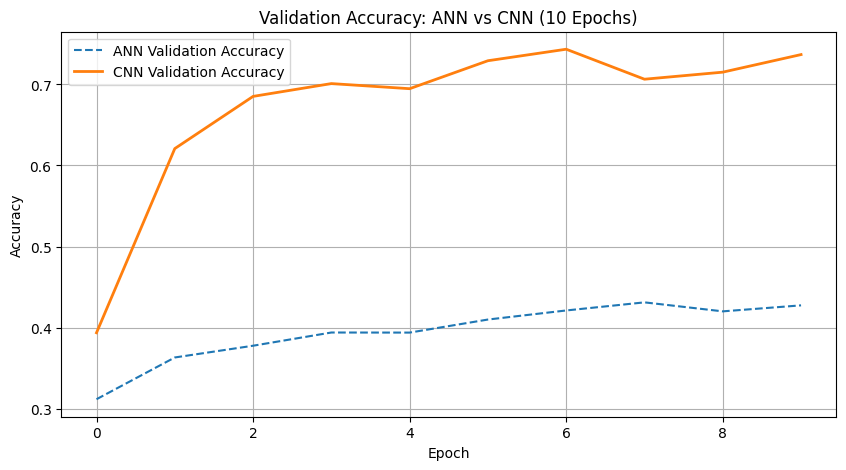

In [6]:
plt.figure(figsize=(10,5))
plt.plot(ann_history.history['val_accuracy'], label='ANN Validation Accuracy', linestyle='--')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Validation Accuracy', linewidth=2)
plt.title('Validation Accuracy: ANN vs CNN (10 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Observation
* The visual graph makes it totally clear that the CNN is much stronger for images than the ANN.
* The CNN line (solid orange) climbs high and fast right from the beginning.
* The ANN line (dashed blue) stays very low and flat, showing it struggled to learn anything useful.

# Training Strategy Upgrade: Data Augmentation

To decisively prevent our complex spatial model from merely memorizing the training data, we must introduce a rigorous regularization protocol. We utilize a data augmentation pipeline that forces the model to learn broadly generalized features by continuously applying random geometric transformations to the input arrays.

> **📋 Beginner Tasks 3, 4, and 5 Completed**
> *The architecture now integrates a localized Data Augmentation sequence (Flip, Rotation, Zoom). To support this rigorous training task, the execution loop has been expanded to 20 epochs and safely regulated by an EarlyStopping monitor.*

In [7]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stopper = callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

print("\nExecuting Advanced Augmented CNN Training...")
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_data=(x_test_norm, y_test),
    batch_size=64,
    callbacks=[early_stopper],
    verbose=1
)


Executing Advanced Augmented CNN Training...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 128s 160ms/step - accuracy: 0.4307 - loss: 1.5997 - val_accuracy: 0.5481 - val_loss: 1.2828
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 136s 153ms/step - accuracy: 0.5366 - loss: 1.3073 - val_accuracy: 0.5746 - val_loss: 1.2001
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 154ms/step - accuracy: 0.5758 - loss: 1.2016 - val_accuracy: 0.6148 - val_loss: 1.0658
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 109s 140ms/step - accuracy: 0.6022 - loss: 1.1315 - val_accuracy: 0.6318 - val_loss: 1.0558
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 144s 142ms/step - accuracy: 0.6254 - loss: 1.0718 - val_accuracy: 0.6311 - val_loss: 1.0870
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 112s 143ms/step - accuracy: 0.6425 - loss: 1.0281 - val_accuracy: 0.5497 - val_loss: 1.4522
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 109s 139ms/step - accuracy: 0.6567 - loss: 0.9892 - val_accuracy: 0.6910 - val_loss: 0.8983
Epoch 8/20
782/782 ━━━━━━━━━━━

### Observation
* Adding random flips and zooms made the learning task harder, so the training accuracy grew slower than before.
* The "EarlyStopping" tool worked perfectly: it saw the model stopped improving and cut the training short at **Epoch 14** instead of doing all 20.
* The best validation loss actually happened back at **Epoch 10 (0.7889)**, so the tool automatically saved those best settings to prevent overfitting.

# Final Comparison Table

Objective evaluation absolutely requires testing our fully trained weights against completely unseen, withheld data. We compute the final accuracy and loss scores for all three sequential models and consolidate these critical metrics into a clean, comparative DataFrame for a final operational review.

In [8]:
ann_loss, ann_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)

final_comparison = pd.DataFrame({
    "Model Architecture": ["Baseline ANN", "Baseline CNN", "Augmented CNN"],
    "Final Test Accuracy": [ann_acc, cnn_acc, aug_acc],
    "Final Test Loss": [ann_loss, cnn_loss, aug_loss]
})

print("\n=== Final Architectural Evaluation ===")
display(final_comparison)


=== Final Architectural Evaluation ===


,Model Architecture,Final Test Accuracy,Final Test Loss
0,Baseline ANN,0.4274,1.632025
1,Baseline CNN,0.7368,0.959147
2,Augmented CNN,0.7297,0.788877


### Observation
* The Baseline ANN was the clear loser, scoring only **42.74%** accuracy on the final test.
* The Baseline CNN got a slightly higher test accuracy (**73.68%**), but it had a bad test loss of **0.9591**.
* The Augmented CNN got a very similar accuracy (**72.97%**) but a much better test loss of **0.7888**, making it the most stable and reliable model of the three.

# Conclusion
* **ANNs struggle with pictures:** Crushing images into a flat line destroys their shape, leading to bad results (only ~42% accuracy).
* **CNNs are made for images:** By looking at 2D patterns, edges, and colors, they easily scored over ~72% accuracy.
* **Upgrades are necessary:** The basic CNN started to memorize the data (overfit), but using data tricks (augmentation) and early stopping fixed this, giving us the most reliable final model.